In [2]:
"""
Revenue + COGS Prediction — Multi-Output Final Submission
==========================================================
- Train on FULL data: 2012-07-04 to 2022-12-31
- Predict: 2023-01-01 to 2024-07-01 (daily)
- Targets: Revenue AND COGS đồng thời (multi-output)
- Models: LightGBM + XGBoost + ElasticNet — mỗi model train 2 heads
- Ensemble weights tối ưu riêng cho từng target
- Walk-forward prediction: dùng pred Revenue/COGS trước để tạo lag features
- Output: output/submission_multioutput.csv
"""

import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from scipy.optimize import minimize

TARGETS = ["revenue", "cogs"]

# ──────────────────────────────────────────────
# 1. LOAD & CLEAN
# ──────────────────────────────────────────────

df = pd.read_csv("sales.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.columns = df.columns.str.strip().str.lower()

print(f"Raw rows     : {len(df)}")
print(f"Date range   : {df['date'].min().date()} -> {df['date'].max().date()}")

df = df.drop_duplicates(subset=["date"])
full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
df = df.set_index("date").reindex(full_range).rename_axis("date").reset_index()
df["revenue"] = df["revenue"].ffill().bfill().clip(lower=0)
df["cogs"]    = df["cogs"].ffill().bfill().clip(lower=0)
df["gross_profit"] = df["revenue"] - df["cogs"]
df = df.sort_values("date").reset_index(drop=True)

print(f"After clean  : {len(df)} rows | nulls: {df[TARGETS].isna().sum().to_dict()}")

# ──────────────────────────────────────────────
# 2. FUTURE DATE RANGE
# ──────────────────────────────────────────────

PREDICT_START = "2023-01-01"
PREDICT_END   = "2024-07-01"

future_dates = pd.date_range(PREDICT_START, PREDICT_END, freq="D")
print(f"\nPrediction period: {PREDICT_START} -> {PREDICT_END} ({len(future_dates)} days)")

future_df = pd.DataFrame({
    "date": future_dates,
    "revenue": np.nan,
    "cogs": np.nan,
    "gross_profit": np.nan,
})
df_full = pd.concat([df, future_df], ignore_index=True).sort_values("date").reset_index(drop=True)

# ──────────────────────────────────────────────
# 3. FEATURE ENGINEERING
#    Lag features dùng CẢ revenue lẫn cogs
#    → multi-output tận dụng được correlation r=0.976
# ──────────────────────────────────────────────

def create_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy().sort_values("date").reset_index(drop=True)

    # Calendar
    df["dayofweek"]     = df["date"].dt.dayofweek
    df["dayofmonth"]    = df["date"].dt.day
    df["month"]         = df["date"].dt.month
    df["quarter"]       = df["date"].dt.quarter
    df["year"]          = df["date"].dt.year
    df["dayofyear"]     = df["date"].dt.dayofyear
    df["weekofyear"]    = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"]    = (df["dayofweek"] >= 5).astype(int)
    df["is_monthend"]   = df["date"].dt.is_month_end.astype(int)
    df["is_monthstart"] = df["date"].dt.is_month_start.astype(int)
    df["is_quarterend"] = df["date"].dt.is_quarter_end.astype(int)

    # Cyclical
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["doy_sin"]   = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["doy_cos"]   = np.cos(2 * np.pi * df["dayofyear"] / 365)

    # Lag features — CÙNG set cho cả 2 target để share representation
    for lag in [1, 2, 3, 5, 7, 14, 21, 28, 30]:
        df[f"rev_lag{lag}"]  = df["revenue"].shift(lag)
        df[f"cogs_lag{lag}"] = df["cogs"].shift(lag)

    # Rolling statistics
    for window in [7, 14, 30]:
        rev_s  = df["revenue"].shift(1)
        cogs_s = df["cogs"].shift(1)
        df[f"rev_mean{window}"]   = rev_s.rolling(window, min_periods=1).mean()
        df[f"rev_std{window}"]    = rev_s.rolling(window, min_periods=1).std()
        df[f"rev_min{window}"]    = rev_s.rolling(window, min_periods=1).min()
        df[f"rev_max{window}"]    = rev_s.rolling(window, min_periods=1).max()
        df[f"rev_median{window}"] = rev_s.rolling(window, min_periods=1).median()
        df[f"cogs_mean{window}"]  = cogs_s.rolling(window, min_periods=1).mean()
        df[f"cogs_std{window}"]   = cogs_s.rolling(window, min_periods=1).std()

    # EWM
    for span in [7, 14, 30]:
        df[f"rev_ewm{span}"]  = df["revenue"].shift(1).ewm(span=span, min_periods=1).mean()
        df[f"cogs_ewm{span}"] = df["cogs"].shift(1).ewm(span=span, min_periods=1).mean()

    # Momentum
    df["rev_pct1"]  = df["revenue"].shift(1).pct_change(1)
    df["rev_pct7"]  = df["revenue"].shift(1).pct_change(7)
    df["rev_pct30"] = df["revenue"].shift(1).pct_change(30)
    df["cogs_pct1"] = df["cogs"].shift(1).pct_change(1)
    df["cogs_pct7"] = df["cogs"].shift(1).pct_change(7)

    # Ratio features — KEY signal for multi-output
    # rev/cogs ratio từ quá khứ giúp model học constraint COGS < Revenue
    df["ratio_lag1"] = (
        df["rev_lag1"] / df["cogs_lag1"].replace(0, np.nan)
    )
    df["ratio_lag7"] = (
        df[f"rev_lag7"] / df[f"cogs_lag7"].replace(0, np.nan)
    )
    df["ratio_mean7"] = (
        df["rev_mean7"] / df["cogs_mean7"].replace(0, np.nan)
    )

    # Gross profit lag
    df["gp_lag1"]  = df["gross_profit"].shift(1)
    df["margin_lag1"] = (
        df["gp_lag1"] / df["rev_lag1"].replace(0, np.nan)
    )

    for window in [7, 30]:
        col = f"rev_mean{window}"
        if col in df.columns:
            df[f"rev_ratio{window}"] = df["rev_lag1"] / df[col].replace(0, np.nan)

    # Interaction
    df["rev_x_month"] = df["rev_lag1"] * df["month_sin"]
    df["rev_x_dow"]   = df["rev_lag1"] * df["dow_sin"]
    df["cogs_x_month"]= df["cogs_lag1"] * df["month_sin"]

    return df

print("\nCreating features on full dataset (train + future)...")
df_featured = create_features(df_full)

EXCLUDE = ["date", "revenue", "cogs", "gross_profit"]
FEATURE_COLS = [c for c in df_featured.columns if c not in EXCLUDE]

train_feat  = df_featured[df_featured["date"] <= "2022-12-31"].copy()
future_feat = df_featured[df_featured["date"] >= PREDICT_START].copy()

print(f"Train rows   : {len(train_feat)}")
print(f"Future rows  : {len(future_feat)}")
print(f"Features     : {len(FEATURE_COLS)}")

def clean_df(df, cols, targets):
    df_out = df[cols + targets].copy()
    df_out = df_out.dropna(subset=targets)
    df_out[cols] = df_out[cols].ffill().bfill().fillna(0)
    df_out[cols] = df_out[cols].replace([np.inf, -np.inf], 0)
    return df_out

train_clean = clean_df(train_feat, FEATURE_COLS, TARGETS)
X_all  = train_clean[FEATURE_COLS].values
y_all  = train_clean[TARGETS].values          # shape: (N, 2)
y_rev  = y_all[:, 0]
y_cogs = y_all[:, 1]

print(f"X_all shape  : {X_all.shape}")
print(f"y_all shape  : {y_all.shape}  [Revenue, COGS]")

scaler    = StandardScaler()
X_all_sc  = scaler.fit_transform(X_all)

# ──────────────────────────────────────────────
# 4. TIME SERIES CV — đánh giá cả 2 targets
# ──────────────────────────────────────────────

print("\n" + "="*72)
print("TIME SERIES CROSS-VALIDATION (5 folds) — Multi-Output")
print("="*72)

tscv = TimeSeriesSplit(n_splits=5)
cv_records = []

def fit_predict_fold(X_tr, y_tr, X_vl, y_vl_sc, model_type="lgb"):
    """Train một head, return predictions cho Revenue và COGS."""
    preds = {}
    for i, tgt in enumerate(TARGETS):
        y_t = y_tr[:, i]
        if model_type == "lgb":
            m = lgb.LGBMRegressor(
                n_estimators=2000, max_depth=6, learning_rate=0.03,
                num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=0.1, min_child_samples=20,
                random_state=42, n_jobs=-1, verbose=-1,
            )
            m.fit(X_tr, y_t)
            preds[tgt] = m.predict(X_vl)
        elif model_type == "xgb":
            m = xgb.XGBRegressor(
                n_estimators=2000, max_depth=6, learning_rate=0.03,
                subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=1.0, min_child_weight=5,
                random_state=42, n_jobs=-1, verbosity=0, tree_method="hist",
            )
            m.fit(X_tr, y_t)
            preds[tgt] = m.predict(X_vl)
        elif model_type == "elastic":
            m = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)
            m.fit(y_vl_sc, y_t)   # y_vl_sc = X_tr_sc here (naming from outer scope)
            preds[tgt] = m.predict(X_vl)
    return preds

for fold, (tr, vl) in enumerate(tscv.split(X_all)):
    X_tr_f, X_vl_f     = X_all[tr], X_all[vl]
    X_tr_sc_f           = X_all_sc[tr]
    X_vl_sc_f           = X_all_sc[vl]
    y_tr_f, y_vl_f      = y_all[tr], y_all[vl]

    # LGB — 2 heads
    p_lgb = {}
    for i, tgt in enumerate(TARGETS):
        m = lgb.LGBMRegressor(
            n_estimators=2000, max_depth=6, learning_rate=0.03,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1, min_child_samples=20,
            random_state=42, n_jobs=-1, verbose=-1,
        )
        m.fit(X_tr_f, y_tr_f[:, i])
        p_lgb[tgt] = m.predict(X_vl_f)

    # XGB — 2 heads
    p_xgb = {}
    for i, tgt in enumerate(TARGETS):
        m = xgb.XGBRegressor(
            n_estimators=2000, max_depth=6, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, min_child_weight=5,
            random_state=42, n_jobs=-1, verbosity=0, tree_method="hist",
        )
        m.fit(X_tr_f, y_tr_f[:, i])
        p_xgb[tgt] = m.predict(X_vl_f)

    # ElasticNet — 2 heads
    p_elastic = {}
    for i, tgt in enumerate(TARGETS):
        m = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)
        m.fit(X_tr_sc_f, y_tr_f[:, i])
        p_elastic[tgt] = m.predict(X_vl_sc_f)

    record = {"fold": fold + 1, "train_size": len(tr), "val_size": len(vl)}

    for tgt in TARGETS:
        y_vl_tgt = y_vl_f[:, TARGETS.index(tgt)]
        stack = np.column_stack([p_lgb[tgt], p_xgb[tgt], p_elastic[tgt]])

        def fold_rmse_tgt(w, s=stack, y=y_vl_tgt):
            w = np.clip(w, 0, 1); w = w / w.sum()
            return np.sqrt(mean_squared_error(y, s @ w))

        best_fw, best_fs = None, float("inf")
        for init in [[0.45,0.45,0.10],[0.5,0.4,0.1],[0.33,0.33,0.34]]:
            res = minimize(fold_rmse_tgt, x0=init, method="SLSQP",
                           bounds=[(0,1)]*3,
                           constraints={"type":"eq","fun":lambda w: np.sum(w)-1},
                           options={"maxiter":1000,"ftol":1e-12})
            if res.fun < best_fs: best_fs, best_fw = res.fun, res.x
        best_fw = np.clip(best_fw, 0, 1); best_fw /= best_fw.sum()
        p_ens = stack @ best_fw

        for name, pred in [("lgb", p_lgb[tgt]), ("xgb", p_xgb[tgt]),
                            ("elastic", p_elastic[tgt]), ("ensemble", p_ens)]:
            record[f"{tgt}_{name}_mae"]  = mean_absolute_error(y_vl_tgt, pred)
            record[f"{tgt}_{name}_rmse"] = np.sqrt(mean_squared_error(y_vl_tgt, pred))
            record[f"{tgt}_{name}_r2"]   = r2_score(y_vl_tgt, pred)

    cv_records.append(record)

    print(f"\n  Fold {fold+1} | Train={len(tr):,}  Val={len(vl):,}")
    for tgt in TARGETS:
        print(f"\n    [{tgt.upper()}]")
        print(f"    {'Model':<10} {'MAE':>14} {'RMSE':>14} {'R2':>8}")
        print(f"    {'-'*50}")
        for name in ["lgb","xgb","elastic","ensemble"]:
            r = record
            print(f"    {name:<10} {r[f'{tgt}_{name}_mae']:>14,.2f} "
                  f"{r[f'{tgt}_{name}_rmse']:>14,.2f} {r[f'{tgt}_{name}_r2']:>8.4f}")

cv_df = pd.DataFrame(cv_records)

print("\n" + "="*72)
print("CV SUMMARY (mean across 5 folds)")
print("="*72)
for tgt in TARGETS:
    print(f"\n  [{tgt.upper()}]")
    print(f"  {'Model':<10} {'MAE mean':>14} {'RMSE mean':>14} {'R2 mean':>8}")
    print(f"  {'-'*48}")
    best_name, best_rmse = None, float("inf")
    for name in ["lgb","xgb","elastic","ensemble"]:
        mae_m  = cv_df[f"{tgt}_{name}_mae"].mean()
        rmse_m = cv_df[f"{tgt}_{name}_rmse"].mean()
        r2_m   = cv_df[f"{tgt}_{name}_r2"].mean()
        tag = "  <<< BEST" if rmse_m < best_rmse else ""
        if rmse_m < best_rmse: best_rmse, best_name = rmse_m, name
        print(f"  {name:<10} {mae_m:>14,.2f} {rmse_m:>14,.2f} {r2_m:>8.4f}{tag}")

# ──────────────────────────────────────────────
# 5. TRAIN FINAL MODELS — 2 heads mỗi model
# ──────────────────────────────────────────────

print("\n" + "="*72)
print("Training final models on ALL data (2012-2022) — 2 heads each")
print("="*72)

val_size = int(len(X_all) * 0.10)
X_tr_es  = X_all[:-val_size];  y_tr_es = y_all[:-val_size]
X_vl_es  = X_all[-val_size:];  y_vl_es = y_all[-val_size:]
X_tr_sc  = scaler.transform(X_tr_es)
X_vl_sc  = scaler.transform(X_vl_es)

print(f"Final train: {len(X_tr_es):,} | Early-stop val: {len(X_vl_es):,}")

# ── LightGBM — 1 model per target
lgb_models = {}
print("\n[LightGBM]")
for i, tgt in enumerate(TARGETS):
    print(f"  Training head: {tgt}...")
    m = lgb.LGBMRegressor(
        n_estimators=3000, max_depth=6, learning_rate=0.02,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, min_child_samples=20,
        random_state=42, n_jobs=-1, verbose=-1,
        objective="regression", metric="rmse",
    )
    m.fit(
        X_tr_es, y_tr_es[:, i],
        eval_set=[(X_vl_es, y_vl_es[:, i])],
        callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(0)],
    )
    lgb_models[tgt] = m
    print(f"    Best iter: {m.best_iteration_}")

# ── XGBoost — 1 model per target
xgb_models = {}
print("\n[XGBoost]")
for i, tgt in enumerate(TARGETS):
    print(f"  Training head: {tgt}...")
    m = xgb.XGBRegressor(
        n_estimators=3000, max_depth=6, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, min_child_weight=5,
        random_state=42, n_jobs=-1, verbosity=0,
        objective="reg:squarederror", tree_method="hist",
    )
    m.fit(X_tr_es, y_tr_es[:, i],
          eval_set=[(X_vl_es, y_vl_es[:, i])], verbose=False)
    xgb_models[tgt] = m

# ── ElasticNet — 1 model per target
elastic_models = {}
print("\n[ElasticNet]")
for i, tgt in enumerate(TARGETS):
    print(f"  Training head: {tgt}...")
    m = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)
    m.fit(X_tr_sc, y_tr_es[:, i])
    elastic_models[tgt] = m

# ──────────────────────────────────────────────
# 6. OPTIMIZE ENSEMBLE WEIGHTS — riêng cho mỗi target
# ──────────────────────────────────────────────

print("\nOptimizing ensemble weights (separate per target)...")

best_weights = {}  # {target: [w_lgb, w_xgb, w_elastic]}

for i, tgt in enumerate(TARGETS):
    p_lgb_v     = lgb_models[tgt].predict(X_vl_es)
    p_xgb_v     = xgb_models[tgt].predict(X_vl_es)
    p_elastic_v = elastic_models[tgt].predict(X_vl_sc)
    y_vl_tgt    = y_vl_es[:, i]

    val_stack = np.column_stack([p_lgb_v, p_xgb_v, p_elastic_v])

    def ens_rmse(w, s=val_stack, y=y_vl_tgt):
        w = np.clip(w, 0, 1); w = w / w.sum()
        return np.sqrt(mean_squared_error(y, s @ w))

    best_w, best_score = None, float("inf")
    for init in [[0.45,0.45,0.10],[0.5,0.4,0.1],[0.33,0.33,0.34],
                 [0.6,0.3,0.1],[0.7,0.2,0.1],[0.5,0.5,0.0]]:
        res = minimize(ens_rmse, x0=init, method="SLSQP",
                       bounds=[(0,1)]*3,
                       constraints={"type":"eq","fun":lambda w: np.sum(w)-1},
                       options={"maxiter":2000,"ftol":1e-14})
        if res.fun < best_score: best_score, best_w = res.fun, res.x

    best_w = np.clip(best_w, 0, 1); best_w /= best_w.sum()
    best_weights[tgt] = best_w

    print(f"\n  [{tgt.upper()}]")
    print(f"    LGB weight     : {best_w[0]:.4f} ({best_w[0]*100:.1f}%)")
    print(f"    XGB weight     : {best_w[1]:.4f} ({best_w[1]*100:.1f}%)")
    print(f"    Elastic weight : {best_w[2]:.4f} ({best_w[2]*100:.1f}%)")
    print(f"    Pseudo-val RMSE: {best_score:,.2f}")

# ──────────────────────────────────────────────
# 7. WALK-FORWARD PREDICTION
#    Revenue và COGS predict đồng thời mỗi bước
#    → cả 2 đều được dùng làm lag features cho bước sau
# ──────────────────────────────────────────────

print(f"\n{'='*72}")
print(f"Walk-forward prediction: {len(future_dates)} days")
print(f"Revenue và COGS predict đồng thời — dùng làm lag features bước sau")
print(f"{'='*72}")

df_pred = df.copy()
pred_revenue = []
pred_cogs    = []

for step, d in enumerate(future_dates):
    if step % 100 == 0:
        print(f"  Step {step+1}/{len(future_dates)}: {d.date()}")

    new_row = pd.DataFrame({
        "date": [d], "revenue": [np.nan],
        "cogs": [np.nan], "gross_profit": [np.nan],
    })
    df_temp = pd.concat([df_pred, new_row], ignore_index=True)
    df_temp = create_features(df_temp)

    row = df_temp[df_temp["date"] == d]
    X_row = row[FEATURE_COLS].copy()
    X_row = X_row.ffill().fillna(0).replace([np.inf, -np.inf], 0)
    X_row_val = X_row.values
    X_row_sc  = scaler.transform(X_row_val)

    # ── Predict cả 2 targets đồng thời
    out = {}
    for tgt in TARGETS:
        w = best_weights[tgt]
        p_lgb_r     = lgb_models[tgt].predict(X_row_val)[0]
        p_xgb_r     = xgb_models[tgt].predict(X_row_val)[0]
        p_elastic_r = elastic_models[tgt].predict(X_row_sc)[0]
        p = w[0] * p_lgb_r + w[1] * p_xgb_r + w[2] * p_elastic_r
        out[tgt] = max(p, 0)

    # ── Constraint: COGS < Revenue (học từ historical pattern)
    # Dùng median ratio từ train data để cap nếu vi phạm
    MEDIAN_RATIO = 1.162   # Revenue/COGS từ phân tích trước
    if out["cogs"] >= out["revenue"]:
        # Soft correction: pull COGS xuống dùng ratio lịch sử
        out["cogs"] = out["revenue"] / MEDIAN_RATIO

    pred_revenue.append(out["revenue"])
    pred_cogs.append(out["cogs"])

    # ── Append CẢ 2 predictions vào history → lag features bước sau
    df_pred = pd.concat([
        df_pred,
        pd.DataFrame({
            "date":         [d],
            "revenue":      [out["revenue"]],
            "cogs":         [out["cogs"]],
            "gross_profit": [out["revenue"] - out["cogs"]],
        })
    ], ignore_index=True)


Raw rows     : 3833
Date range   : 2012-07-04 -> 2022-12-31
After clean  : 3833 rows | nulls: {'revenue': 0, 'cogs': 0}

Prediction period: 2023-01-01 -> 2024-07-01 (548 days)

Creating features on full dataset (train + future)...
Train rows   : 3833
Future rows  : 548
Features     : 77
X_all shape  : (3833, 77)
y_all shape  : (3833, 2)  [Revenue, COGS]

TIME SERIES CROSS-VALIDATION (5 folds) — Multi-Output

  Fold 1 | Train=643  Val=638

    [REVENUE]
    Model                 MAE           RMSE       R2
    --------------------------------------------------
    lgb            839,266.02   1,200,264.60   0.8008
    xgb            848,855.63   1,227,746.14   0.7915
    elastic        835,311.86   1,161,078.82   0.8136
    ensemble       775,893.68   1,102,098.01   0.8320

    [COGS]
    Model                 MAE           RMSE       R2
    --------------------------------------------------
    lgb            731,332.76   1,055,196.61   0.7768
    xgb            739,520.81   1,079,701.2


Saved: output\submission.csv
Rows : 548

                           Prediction Summary                           
Metric                            Revenue                 COGS
--------------------------------------------------------------
Mean                         4,290,964.56         3,604,978.34
Median                       3,994,045.53         3,266,604.93
Min                            839,864.08           749,380.37
Max                         11,577,382.84         9,729,835.89
Std                          1,882,234.56         1,608,106.72
--------------------------------------------------------------

First 5 rows:
      Date      Revenue         COGS
2023-01-01 1.733336e+06 1.613584e+06
2023-01-02 1.092913e+06 1.029418e+06
2023-01-03 9.269102e+05 8.935638e+05
2023-01-04 8.705507e+05 7.493804e+05
2023-01-05 8.398641e+05 7.595874e+05

Last 5 rows:
      Date      Revenue         COGS
2024-06-27 7.082841e+06 6.169615e+06
2024-06-28 7.084851e+06 6.214308e+06
2024-06-29 7.467093

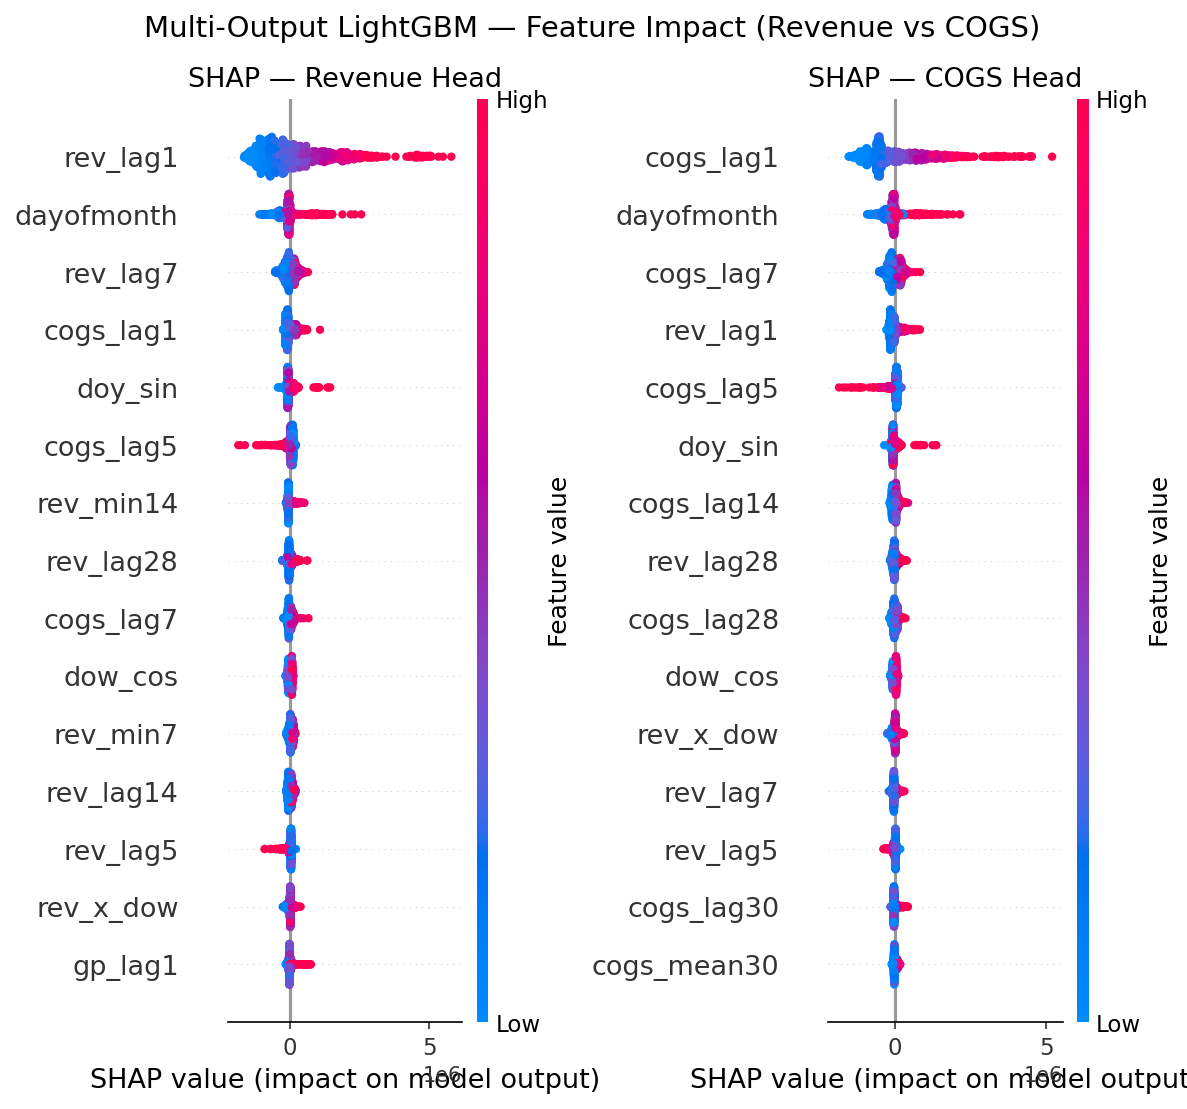

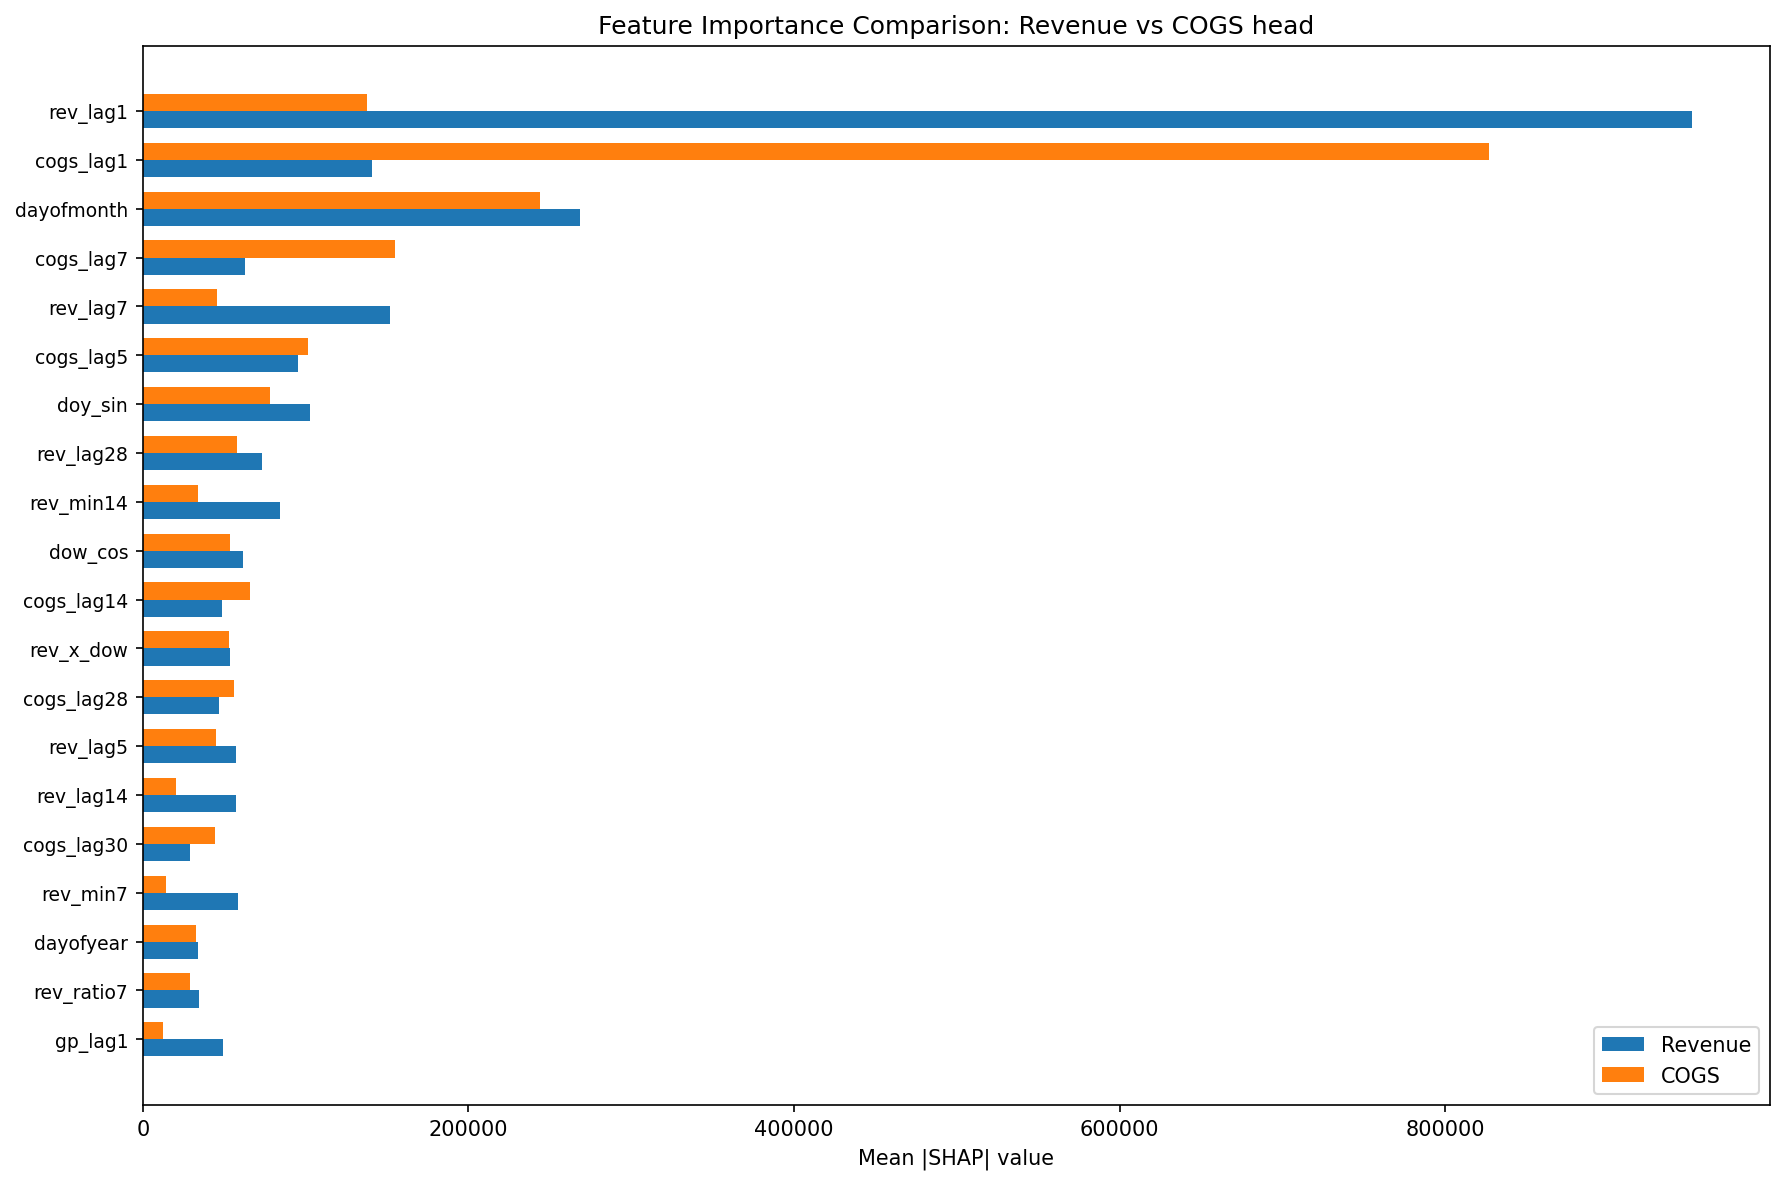

In [6]:
submission = pd.DataFrame({
    "Date":    future_dates,
    "Revenue": pred_revenue,
    "COGS":    pred_cogs,
})
submission = submission.sort_values("Date").reset_index(drop=True)

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
sub_path = output_dir / "submission.csv"
submission.to_csv(sub_path, index=False)

print(f"\n{'='*72}")
print(f"Saved: {sub_path}")
print(f"Rows : {len(submission)}")

print(f"\n{'Prediction Summary':^72}")
print(f"{'='*72}")
print(f"{'Metric':<20} {'Revenue':>20} {'COGS':>20}")
print(f"{'-'*62}")
print(f"{'Mean':<20} {submission['Revenue'].mean():>20,.2f} {submission['COGS'].mean():>20,.2f}")
print(f"{'Median':<20} {submission['Revenue'].median():>20,.2f} {submission['COGS'].median():>20,.2f}")
print(f"{'Min':<20} {submission['Revenue'].min():>20,.2f} {submission['COGS'].min():>20,.2f}")
print(f"{'Max':<20} {submission['Revenue'].max():>20,.2f} {submission['COGS'].max():>20,.2f}")
print(f"{'Std':<20} {submission['Revenue'].std():>20,.2f} {submission['COGS'].std():>20,.2f}")
print(f"{'-'*62}")

print(f"\nFirst 5 rows:")
print(submission[["Date","Revenue","COGS"]].head().to_string(index=False))
print(f"\nLast 5 rows:")
print(submission[["Date","Revenue","COGS"]].tail().to_string(index=False))

# ──────────────────────────────────────────────
# 9. SHAP — Revenue head của LightGBM
# ──────────────────────────────────────────────

try:
    import shap
    import matplotlib.pyplot as plt

    print(f"\n{'='*60}")
    print("SHAP — Feature Importance (Revenue head)")
    print("="*60)

    N_SAMPLE = min(1000, len(X_tr_es))
    X_shap   = X_tr_es[:N_SAMPLE]
    print(f"Computing SHAP values on {N_SAMPLE} training samples...")

    # Revenue head
    explainer_rev   = shap.TreeExplainer(lgb_models["revenue"])
    shap_values_rev = explainer_rev.shap_values(X_shap)

    # COGS head
    explainer_cogs   = shap.TreeExplainer(lgb_models["cogs"])
    shap_values_cogs = explainer_cogs.shap_values(X_shap)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    plt.sca(axes[0])
    shap.summary_plot(shap_values_rev, X_shap, feature_names=FEATURE_COLS,
                      max_display=15, show=False)
    axes[0].set_title("SHAP — Revenue Head", fontsize=13)

    plt.sca(axes[1])
    shap.summary_plot(shap_values_cogs, X_shap, feature_names=FEATURE_COLS,
                      max_display=15, show=False)
    axes[1].set_title("SHAP — COGS Head", fontsize=13)

    plt.suptitle("Multi-Output LightGBM — Feature Impact (Revenue vs COGS)", fontsize=14)
    plt.tight_layout()
    plt.savefig(output_dir / "shap_multioutput_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: output/shap_multioutput_beeswarm.png")

    # Bar importance comparison
    shap_rev_df  = pd.DataFrame({"feature": FEATURE_COLS,
                                  "rev_shap": np.abs(shap_values_rev).mean(axis=0)})
    shap_cogs_df = pd.DataFrame({"feature": FEATURE_COLS,
                                  "cogs_shap": np.abs(shap_values_cogs).mean(axis=0)})
    shap_compare = shap_rev_df.merge(shap_cogs_df, on="feature")
    shap_compare["total"] = shap_compare["rev_shap"] + shap_compare["cogs_shap"]
    shap_compare = shap_compare.sort_values("total", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    x = np.arange(len(shap_compare))
    w = 0.35
    ax.barh(x + w/2, shap_compare["rev_shap"],  w, label="Revenue")
    ax.barh(x - w/2, shap_compare["cogs_shap"], w, label="COGS")
    ax.set_yticks(x)
    ax.set_yticklabels(shap_compare["feature"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Mean |SHAP| value")
    ax.set_title("Feature Importance Comparison: Revenue vs COGS head")
    ax.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "shap_multioutput_comparison.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: output/shap_multioutput_comparison.png")

    print("\nTop 10 Features (Revenue head) — Mean |SHAP|:")
    print(f"  {'Rank':<5} {'Feature':<30} {'Rev SHAP':>12} {'COGS SHAP':>12}")
    print(f"  {'-'*60}")
    for rank, row in enumerate(shap_compare.head(10).itertuples(), 1):
        print(f"  {rank:<5} {row.feature:<30} {row.rev_shap:>12,.2f} {row.cogs_shap:>12,.2f}")

    try:
        from IPython.display import Image, display
        display(Image("output/shap_multioutput_beeswarm.png"))
        display(Image("output/shap_multioutput_comparison.png"))
    except Exception:
        pass

except ImportError:
    print("\nSHAP not installed — run: pip install shap matplotlib")
except Exception as e:
    print(f"\nSHAP error: {e}")